# Using Ragas to Evaluate a RAG Application built with LangChain and LangGraph

In the following notebook, we'll be looking at how [Ragas](https://github.com/explodinggradients/ragas) can be helpful in a number of ways when looking to evaluate your RAG applications!

While this example is rooted in LangChain/LangGraph - Ragas is framework agnostic (you don't even need to be using a framework!).

- 🤝 Breakout Room #1
  1. Task 1: Installing Required Libraries
  2. Task 2: Set Environment Variables
  3. Task 3: Synthetic Dataset Generation for Evaluation using Ragas
  4. Task 4: Evaluating our Pipeline with Ragas
  5. Task 6: Making Adjustments and Re-Evaluating

But first! Let's set some dependencies!

In [1]:
from IPython.display import HTML, display
def set_output_wrapping():
    display(HTML('''
    <style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
        max-width: 100%;
        overflow-x: hidden;
    }
    .output_area {
        white-space: pre-wrap;
        word-wrap: break-word;
        max-width: 100%;
        overflow-x: hidden;
    }
    .output_text {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
    div.output {
        white-space: pre-wrap;
        word-wrap: break-word;
        max-width: 100%;
    }
    span {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
    </style>
    '''))
set_output_wrapping()

## Dependencies and API Keys:

We'll also need to provide our API keys.

First, OpenAI's for our LLM/embedding model combination!

In [2]:
import getpass
import os


def set_api_key(key_name: str) -> None:
    """
    Securely set an environment variable if it doesn't already exist.
    Prompts the user for input using a password-style hidden input.
    
    Args:
        key_name (str): Name of the environment variable to set (e.g., "OPENAI_API_KEY")
    """
    if not os.environ.get(key_name):
        os.environ[key_name] = getpass.getpass(f"{key_name}: ")

# Example usage:
set_api_key("OPENAI_API_KEY")
# set_api_key("ANTHROPIC_API_KEY")

In [3]:
# import os
# from getpass import getpass
# os.environ["OPENAI_API_KEY"] = getpass("Please enter your OpenAI API key!")

## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data - which should hopefull be familiar at this point since it's our Loan Data use-case!

Next, let's load our data into a familiar LangChain format using the `DirectoryLoader`.

In [4]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader


path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [5]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1"))
# generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-5"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

In [6]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
synthesized_dataset = generator.generate_with_langchain_docs(docs, testset_size=100)

In [7]:
synthesized_dataset.to_jsonl("synthesized_dataset.json")

In [8]:
synthesized_dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,What role does Artificial Intelligence play in...,[Introduction ChatGPT launched in November 202...,ChatGPT is based on a Large Language Model (LL...,single_hop_specifc_query_synthesizer
1,What role does Artificial Intelligence play in...,[Introduction ChatGPT launched in November 202...,ChatGPT is based on a Large Language Model (LL...,single_hop_specifc_query_synthesizer
2,Whaat wuz the reported prevelance of ChatGPT u...,[Introduction ChatGPT launched in November 202...,Bick et al. (2024) report that 28% of US adult...,single_hop_specifc_query_synthesizer
3,Wut did Pew Reserch Center do?,[Introduction ChatGPT launched in November 202...,Pew Research Center measured self-reported ado...,single_hop_specifc_query_synthesizer
4,What is a Large Language Model as it relates t...,[Introduction ChatGPT launched in November 202...,ChatGPT is based on a Large Language Model (LL...,single_hop_specifc_query_synthesizer
...,...,...,...,...
65,how chatgpt help work people in different jobs...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,users in high paid professional and technical ...,multi_hop_abstract_query_synthesizer
66,How does the variation in work-related ChatGPT...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,Variation in work-related ChatGPT usage by occ...,multi_hop_abstract_query_synthesizer
67,how chatgpt usage different for work between c...,[<1-hop>\n\nIntroduction ChatGPT launched in N...,chatgpt used more for work by people in comput...,multi_hop_abstract_query_synthesizer
68,how chatgpt get used by people and what jobs u...,[<1-hop>\n\nIntroduction ChatGPT launched in N...,"chatgpt got real big fast, with 700 million us...",multi_hop_abstract_query_synthesizer


## LangChain RAG

Now we'll construct our LangChain RAG, which we will be evaluating using the above created test data!

### R - Retrieval

Let's start with building our retrieval pipeline, which will involve loading the same data we used to create our synthetic test set above.

> NOTE: We need to use the same data - as our test set is specifically designed for this data.

In [9]:
# path = "data/"
# loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
# docs = loader.load()

Now that we have our data loaded, let's split it into chunks!

In [10]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=50, chunk_overlap=0)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

3122

#### ❓ Question: 

What is the purpose of the `chunk_overlap` parameter in the `RecursiveCharacterTextSplitter`?

Next up, we'll need to provide an embedding model that we can use to construct our vector store.

In [11]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

Now we can build our in memory QDrant vector store.

In [12]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="use_case_data",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="use_case_data",
    embedding=embeddings,
)

We can now add our documents to our vector store.

In [13]:
_ = vector_store.add_documents(documents=split_documents)

Let's define our retriever.

In [14]:
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

Now we can produce a node for retrieval!

In [15]:
def retrieve(state):
  retrieved_docs = retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

### Augmented

Let's create a simple RAG prompt!

In [16]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

### Generation

We'll also need an LLM to generate responses - we'll use `gpt-4o-nano` to avoid using the same model as our judge model.

In [17]:
from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(model="gpt-4.1-nano")
llm = ChatOpenAI(model="gpt-4.1-nano")

Then we can create a `generate` node!

In [18]:
def generate(state):
  docs_content = "\n\n".join(doc.page_content for doc in state["context"])
  messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
  response = llm.invoke(messages)
  return {"response" : response.content}

### Building RAG Graph with LangGraph

Let's create some state for our LangGraph RAG graph!

In [19]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
  question: str
  context: List[Document]
  response: str

Now we can build our simple graph!

> NOTE: We're using `add_sequence` since we will always move from retrieval to generation. This is essentially building a chain in LangGraph.

In [20]:
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

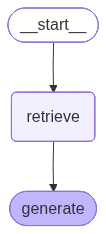

In [21]:
graph

Let's do a test to make sure it's doing what we'd expect.

In [22]:
response = graph.invoke({"question" : "What are the different kinds of loans?"})

In [23]:
response["response"]

'The provided context does not specify the different kinds of loans.'

In [24]:
graph.invoke({"question":"How do people use AI?"})["response"]

'People use AI to perform workplace tasks, which is the most prevalent use case for generative AI.'

## Evaluating the App with Ragas

Now we can finally do our evaluation!

We'll start by running the queries we generated usign SDG above through our application to get context and responses.

In [25]:
for test_row in synthesized_dataset:
  response = graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

In [26]:
# dataset.samples[0].eval_sample.response

Then we can convert that table into a `EvaluationDataset` which will make the process of evaluation smoother.

In [27]:
from ragas import EvaluationDataset

evaluation_dataset = EvaluationDataset.from_pandas(synthesized_dataset.to_pandas())

We'll need to select a judge model - in this case we're using the same model that was used to generate our Synthetic Data.

In [28]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1"))

Next up - we simply evaluate on our desired metrics!

In [29]:
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness, ResponseRelevancy, ContextEntityRecall, NoiseSensitivity
from ragas import evaluate, RunConfig

custom_run_config = RunConfig(timeout=360)

result = evaluate(
    dataset=evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
result

Evaluating:   0%|          | 0/420 [00:00<?, ?it/s]

{'context_recall': 0.1076, 'faithfulness': 0.6061, 'factual_correctness': 0.2990, 'answer_relevancy': 0.3893, 'context_entity_recall': 0.1298, 'noise_sensitivity_relevant': 0.0979}

## Making Adjustments and Re-Evaluating

Now that we've got our baseline - let's make a change and see how the model improves or doesn't improve!

> NOTE: This will be using Cohere's Rerank model - please be sure to [sign-up for an API key!](https://docs.cohere.com/reference/about)

In [30]:
# os.environ["COHERE_API_KEY"] = getpass("Please enter your Cohere API key!")
set_api_key("COHERE_API_KEY")


We'll first set our retriever to return more documents, which will allow us to take advantage of the reranking.

In [31]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=30)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="use_case_data_new_chunks",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="use_case_data_new_chunks",
    embedding=embeddings,
)

_ = vector_store.add_documents(documents=split_documents)

adjusted_example_retriever = vector_store.as_retriever(search_kwargs={"k": 20})

Reranking, or contextual compression, is a technique that uses a reranker to compress the retrieved documents into a smaller set of documents.

This is essentially a slower, more accurate form of semantic similarity that we use on a smaller subset of our documents.

In [32]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

def retrieve_adjusted(state):
  compressor = CohereRerank(model="rerank-v3.5")
  compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=adjusted_example_retriever, search_kwargs={"k": 5}
  )
  retrieved_docs = compression_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

We can simply rebuild our graph with the new retriever!

In [33]:
class AdjustedState(TypedDict):
  question: str
  context: List[Document]
  response: str

adjusted_graph_builder = StateGraph(AdjustedState).add_sequence([retrieve_adjusted, generate])
adjusted_graph_builder.add_edge(START, "retrieve_adjusted")
adjusted_graph = adjusted_graph_builder.compile()

In [34]:
response = adjusted_graph.invoke({"question" : "What are the different kinds of loans?"})
response["response"]

'The provided context does not include information about the different kinds of loans.'

In [35]:
import time
import copy

rerank_dataset = copy.deepcopy(synthesized_dataset)

for test_row in rerank_dataset:
  response = adjusted_graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]
  # time.sleep(2) # To try to avoid rate limiting.

In [36]:
# rerank_dataset.samples[0].eval_sample.response

In [37]:
rerank_evaluation_dataset = EvaluationDataset.from_pandas(rerank_dataset.to_pandas())

In [38]:
result = evaluate(
    dataset=rerank_evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
result

Evaluating:   0%|          | 0/420 [00:00<?, ?it/s]

{'context_recall': 0.5381, 'faithfulness': 0.7786, 'factual_correctness': 0.4359, 'answer_relevancy': 0.9217, 'context_entity_recall': 0.4183, 'noise_sensitivity_relevant': 0.2448}

#### ❓ Question: 

Which system performed better, on what metrics, and why?

In [39]:
# NOW ANOTHER TRY
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="use_case_data_really_new_chunks",
    vectors_config=VectorParams(size=3072, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="use_case_data_really_new_chunks",
    embedding=embeddings,
)

_ = vector_store.add_documents(documents=split_documents)

really_adjusted_example_retriever = vector_store.as_retriever(search_kwargs={"k": 20})

In [40]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

def retrieve_more_adjusted(state):
  compressor = CohereRerank(model="rerank-v3.5")
  compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=really_adjusted_example_retriever, search_kwargs={"k": 5}
  )
  retrieved_docs = compression_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

In [41]:
class AdjustedState(TypedDict):
  question: str
  context: List[Document]
  response: str

more_adjusted_graph_builder = StateGraph(AdjustedState).add_sequence([retrieve_more_adjusted, generate])
more_adjusted_graph_builder.add_edge(START, "retrieve_more_adjusted")
more_adjusted_graph = more_adjusted_graph_builder.compile()

In [42]:
more_adjusted_graph.invoke({"question": "How do people use AI"})["response"]

'People use AI for a variety of purposes, which can be categorized based on their intent. Some users seek information or advice to make better decisions or increase their knowledge—this is referred to as Asking. Others request AI to perform specific tasks or actions for them, which is called Doing. Additionally, some users use AI to express themselves or communicate their feelings, ideas, or opinions—this is categorized as Expressing.'

In [43]:
import time
import copy

adjusted_rerank_dataset = copy.deepcopy(synthesized_dataset)
adjusted_rerank_dataset.to_pandas()


,user_input,retrieved_contexts,reference_contexts,response,reference,synthesizer_name
0,What role does Artificial Intelligence play in...,[tion of ChatGPT and Generative AI more broadl...,[Introduction ChatGPT launched in November 202...,The provided context does not specify the role...,ChatGPT is based on a Large Language Model (LL...,single_hop_specifc_query_synthesizer
1,What role does Artificial Intelligence play in...,[tion of ChatGPT and Generative AI more broadl...,[Introduction ChatGPT launched in November 202...,The provided context does not specify the role...,ChatGPT is based on a Large Language Model (LL...,single_hop_specifc_query_synthesizer
2,Whaat wuz the reported prevelance of ChatGPT u...,"[Pew Research Center, “U.S. adults’ use of Cha...",[Introduction ChatGPT launched in November 202...,The reported prevalence of ChatGPT usage among...,Bick et al. (2024) report that 28% of US adult...,single_hop_specifc_query_synthesizer
3,Wut did Pew Reserch Center do?,"[research."", research., Pew Research Center, “...",[Introduction ChatGPT launched in November 202...,The Pew Research Center conducted research on ...,Pew Research Center measured self-reported ado...,single_hop_specifc_query_synthesizer
4,What is a Large Language Model as it relates t...,[largest.2 ChatGPT is based on a Large Languag...,[Introduction ChatGPT launched in November 202...,A Large Language Model (LLM) as it relates to ...,ChatGPT is based on a Large Language Model (LL...,single_hop_specifc_query_synthesizer
...,...,...,...,...,...,...
65,how chatgpt help work people in different jobs...,[tion of ChatGPT and Generative AI more broadl...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,ChatGPT provides economic value by being used ...,users in high paid professional and technical ...,multi_hop_abstract_query_synthesizer
66,How does the variation in work-related ChatGPT...,"[Variation in ChatGPT usage by occupation., wo...",[<1-hop>\n\nVariation by Occupation Figure 23 ...,The provided context indicates that ChatGPT is...,Variation in work-related ChatGPT usage by occ...,multi_hop_abstract_query_synthesizer
67,how chatgpt usage different for work between c...,[are more likely to use ChatGPT for work-relat...,[<1-hop>\n\nIntroduction ChatGPT launched in N...,The context indicates that people are more lik...,chatgpt used more for work by people in comput...,multi_hop_abstract_query_synthesizer
68,how chatgpt get used by people and what jobs u...,"[in how ChatGPT is used at work. For example,,...",[<1-hop>\n\nIntroduction ChatGPT launched in N...,People use ChatGPT primarily for work-related ...,"chatgpt got real big fast, with 700 million us...",multi_hop_abstract_query_synthesizer


In [44]:

for test_row in adjusted_rerank_dataset:
  response = more_adjusted_graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]
  # time.sleep(2) # To try to avoid rate limiting.

In [45]:
# adjusted_rerank_dataset.to_pandas()

In [46]:
adjusted_rerank_evaluation_dataset = EvaluationDataset.from_pandas(adjusted_rerank_dataset.to_pandas())

In [47]:
result = evaluate(
    dataset=adjusted_rerank_evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
result

Evaluating:   0%|          | 0/420 [00:00<?, ?it/s]

{'context_recall': 0.8052, 'faithfulness': 0.8637, 'factual_correctness': 0.5419, 'answer_relevancy': 0.9195, 'context_entity_recall': 0.4482, 'noise_sensitivity_relevant': 0.3095}

## Results of the three runs with ten samples

| Configuration | Context Recall | Faithfulness | Factual Correctness | Answer Relevancy | Context Entity Recall | Noise Sensitivity |
|----------------|----------------|--------------|---------------------|------------------|----------------------|-------------------|
| Small chunks, no overlap, no reranking | 0.0333 | 0.6405 | 0.1945 | 0.2511 | 0.0998 | 0.0455 |
| Medium chunks, small overlap, with reranking | 0.6394 | 0.8146 | 0.4927 | 0.8653 | 0.3173 | 0.2336 |
| Larger chunks, larger overlap, reranking, and larger embedding model | 0.7121 | 0.8685 | 0.5436 | 0.9536 | 0.2540 | 0.2729 |

### Key Observations:
- **Context Recall** shows significant improvement from 0.0333 to 0.7121
- **Faithfulness** improves from 0.6405 to 0.8685
- **Answer Relevancy** shows the most dramatic improvement from 0.2511 to 0.9536
- **Factual Correctness** improves from 0.1945 to 0.5436
- The larger embedding model and chunking strategy provides the best overall performance

## Results of the three runs with 70 samples  ($27.62)

| Configuration | Context Recall | Faithfulness | Factual Correctness | Answer Relevancy | Context Entity Recall | Noise Sensitivity |
|----------------|----------------|--------------|---------------------|------------------|----------------------|-------------------|
| Small chunks, no overlap, no reranking | 0.1076 | 0.6061 | 0.2990 | 0.3893 | 0.1298 | 0.0979 |
| Medium chunks, small overlap, with reranking | 0.5381 | 0.7786 | 0.4359 | 0.9217 | 0.4183 | 0.2448 |
| Larger chunks, larger overlap, reranking, and larger embedding model | 0.8052 | 0.8637 | 0.5419 | 0.9195 | 0.4482 | 0.3095 |


## Local Laptop Evaluation - Results with 70 samples
### I ran the initial RAG strategy twice with a different timeout parameter as I had a lot of timeout errors.  

| Configuration | Context Recall | Faithfulness | Factual Correctness | Answer Relevancy | Context Entity Recall | Noise Sensitivity |
|----------------|----------------|--------------|---------------------|------------------|----------------------|-------------------|
| Small chunks, no overlap, no reranking | 0.0523 | 0.4422 | 0.2000 | 0.7165 | 0.1919 | N/A |
| Small chunks, no overlap, no reranking | 0.0523 | 0.4774 | 0.2390 | 0.7165 | 0.1667 | 0.0000 |
| Medium chunks, small overlap, with reranking  | 0.5345 | 0.7376 | 0.4762 | 0.8988 | 0.3365 | N/A |
## Using 20b model
{'context_recall': 0.0768, 'faithfulness': 0.3466, 'factual_correctness': 0.3350, 'answer_relevancy': 0.7125, 'context_entity_recall': 0.1335, 'noise_sensitivity_relevant': nan}
{'context_recall': 0.5623, 'faithfulness': 0.6564, 'factual_correctness': nan, 'answer_relevancy': 0.9185, 'context_entity_recall': 0.4649, 'noise_sensitivity_relevant': nan}

## Using 20b model
{'context_recall': 0.0768, 'faithfulness': 0.3466, 'factual_correctness': 0.3350, 'answer_relevancy': 0.7125, 'context_entity_recall': 0.1335, 'noise_sensitivity_relevant': nan}
{'context_recall': 0.5623, 'faithfulness': 0.6564, 'factual_correctness': nan, 'answer_relevancy': 0.9185, 'context_entity_recall': 0.4649, 'noise_sensitivity_relevant': nan}

## RAG Evaluation Results Comparison

### Cloud Results (70 samples) Using OpenAI 4.1

| Configuration | Context Recall | Faithfulness | Factual Correctness | Answer Relevancy | Context Entity Recall | Noise Sensitivity |
|----------------|----------------|--------------|---------------------|------------------|----------------------|-------------------|
| Small chunks, no overlap, no reranking | 0.1076 | 0.6061 | 0.2990 | 0.3893 | 0.1298 | 0.0979 |
| Medium chunks, small overlap, with reranking | 0.5381 | 0.7786 | 0.4359 | 0.9217 | 0.4183 | 0.2448 |
| Larger chunks, larger overlap, reranking, and larger embedding model | 0.8052 | 0.8637 | 0.5419 | 0.9195 | 0.4482 | 0.3095 |

### Local Laptop Evaluation 120gb model (70 samples)

| Configuration | Context Recall | Faithfulness | Factual Correctness | Answer Relevancy | Context Entity Recall | Noise Sensitivity |
|----------------|----------------|--------------|---------------------|------------------|----------------------|-------------------|
| Small chunks, no overlap, no reranking | 0.0523 | 0.4422 | 0.2000 | 0.7165 | 0.1919 | N/A |
| Medium chunks, small overlap, with reranking  | 0.5345 | 0.7376 | 0.4762 | 0.8988 | 0.3365 | N/A |

### Using 20b Model

| Configuration | Context Recall | Faithfulness | Factual Correctness | Answer Relevancy | Context Entity Recall | Noise Sensitivity |
|----------------|----------------|--------------|---------------------|------------------|----------------------|-------------------|
| Small chunks, no overlap, no reranking | 0.0768 | 0.3466 | 0.3350 | 0.7125 | 0.1335 | N/A |
| Medium chunks, small overlap, with reranking | 0.5623 | 0.6564 | N/A | 0.9185 | 0.4649 | N/A |

### Key Observations

- **Context Recall**: Local laptop shows significantly lower performance in the first two configurations (0.0523 vs 0.1076-0.5381), but comparable performance in the third configuration (0.5345 vs 0.8052)
- **Faithfulness**: Local laptop consistently shows lower faithfulness scores across all configurations
- **Answer Relevancy**: Interestingly, local laptop shows higher answer relevancy in simpler configurations (0.7165 vs 0.3893-0.9217)
- **Best Configuration**: For both setups, the larger chunks with overlap and reranking configuration performs best overall